# London Bikes: forecasting daily demand
### Timed group assignment, due 23:59

You work in the analytics team of TfL, Transport for London. Planners want a simple, honest way to understand what drives demand on the bike scheme and to anticipate how busy it will be, so they can move bikes around, schedule maintenance, and staff the docking stations. Your job today is to turn the London bikes dataset into a working model, and to put it in front of them as a live, interactive web dashboard.

By the end of the session your group will have:

1. built and justified your best regression model for daily bike hires,
2. checked it for multicollinearity using the Variance Inflation Factor (VIF),
3. exported that model as a small coefficients file, and
4. used an LLM to build and deploy on Render an **interactive dashboard** that lets a planner explore the bikes dataset and, using weather from Open-Meteo, predicts hires for the **first week of January 2026** and for the next five days.

## What you hand in

Three things:

- **This notebook**, completed, with your modelling, your VIF work, and short written answers where asked.
- **A public GitHub repository** holding the Dash app (`app.py`, `open_meteo.py`, `model_coefficients.csv`, `pyproject.toml`, and the deployment files).
- **A live URL** on Render where the running dashboard can be opened and used.

## How it is marked

| Component | Weight |
|---|---|
| Best model: sensible choice of variables, clear justification, fit statistics | 30 |
| VIF and collinearity: computed, interpreted, and acted on | 20 |
| Diagnostics and interpretation of the final model | 15 |
| Working deployed dashboard on Render (live URL, interactive exploration, and the January 2026 prediction) | 25 |
| Clarity, teamwork, and the short write-ups | 10 |

The deployed app is a required deliverable, not a bonus.


## Splitting the work across 6 to 7 people

A large group only helps if it runs in parallel. One workable split: a **modelling pair** owns Parts 2 and 3, a **diagnostics pair** owns Parts 1 and 4 and the write-ups, a **deployment trio** starts on the LLM dashboard and its Render deployment as soon as Part 5 hands them a `model_coefficients.csv`, and one person coordinates, keeps the clock, and assembles the submission. The deployment team does not have to wait for the perfect model. They can wire everything up against an early model and swap in the final `model_coefficients.csv` at the end.

## Part 0 — Setup

Run the cells below as they are. They load the data, do the same cleaning you saw in the lecture notebook, and define a helper you will use later, `plot_model_diagnostics`, for the four-panel check (VIF you will compute directly with statsmodels). You start from clean data, so you can spend your time on the modelling.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

In [2]:
# Load the data straight from the course repository
bike = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data/london_bikes.csv")

# --- the same cleaning as the lecture notebook ---
bike['date'] = pd.to_datetime(bike['date'])
bike['weekend'] = bike['wday'].isin(['Sat', 'Sun'])

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
bike['day_of_week'] = pd.Categorical(bike['day_of_week'], categories=day_order, ordered=True)

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
bike['month_name'] = pd.Categorical(bike['month_name'], categories=month_order, ordered=True)

# Work with the modern, complete period, as in the lecture
bike = bike[bike['date'] >= pd.to_datetime('2014-01-01', utc=True)].copy()

print("Shape:", bike.shape)
print("Columns:", list(bike.columns))
bike[['date', 'bikes_hired', 'temp', 'feelslike', 'humidity', 'precip', 'windspeed', 'cloudcover', 'day_of_week']].head()

Shape: (4383, 40)
Columns: ['date', 'bikes_hired', 'tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'preciptype', 'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise', 'sunset', 'moonphase', 'conditions', 'description', 'icon', 'month_name', 'month', 'day_of_week', 'wday', 'week', 'year', 'weekend', 'season_name']


,date,bikes_hired,temp,feelslike,humidity,precip,windspeed,cloudcover,day_of_week
1251,2014-01-01 00:00:00+00:00,4327,7.9,4.5,90.0,12.658,32.8,61.5,Wed
1252,2014-01-02 00:00:00+00:00,15820,8.1,5.1,85.3,3.861,30.4,48.4,Thu
1253,2014-01-03 00:00:00+00:00,11636,8.1,4.0,81.3,5.875,43.0,45.3,Fri
1254,2014-01-04 00:00:00+00:00,6918,7.1,3.8,87.4,4.393,29.3,59.1,Sat
1255,2014-01-05 00:00:00+00:00,9145,4.9,1.7,90.0,0.347,30.2,53.6,Sun


In [3]:
# --- Helper: four-panel diagnostics (similar to R's check_model) ---
def plot_model_diagnostics(model):
    residuals = model.resid
    fitted_vals = model.fittedvalues
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    sns.residplot(x=fitted_vals, y=residuals, lowess=True,
                  scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 2}, ax=axes[0, 0])
    axes[0, 0].set_title('Residuals vs Fitted'); axes[0, 0].set_xlabel('Fitted values'); axes[0, 0].set_ylabel('Residuals')

    sm.qqplot(residuals, line='s', ax=axes[0, 1]); axes[0, 1].set_title('Normal Q-Q')

    sqrt_abs_resid = (abs(residuals)) ** 0.5
    axes[1, 0].scatter(fitted_vals, sqrt_abs_resid, alpha=0.5)
    sns.regplot(x=fitted_vals, y=sqrt_abs_resid, scatter=False, lowess=True,
                line_kws={'color': 'red', 'lw': 2}, ax=axes[1, 0])
    axes[1, 0].set_title('Scale-Location'); axes[1, 0].set_xlabel('Fitted values'); axes[1, 0].set_ylabel('sqrt|Standardized Residuals|')

    sm.graphics.influence_plot(model, ax=axes[1, 1], criterion="cooks"); axes[1, 1].set_title('Residuals vs Leverage')
    plt.tight_layout(); plt.show()

# For VIF we use statsmodels' variance_inflation_factor directly (imported above), not a wrapper.
print("Helper ready: plot_model_diagnostics(model)")

Helper ready: plot_model_diagnostics(model)


## Part 1 — Get to know the data

You have the daily hire count in `bikes_hired`, plus a lot of weather (temperature, "feels like", dew point, humidity, precipitation, wind, cloud cover, solar, and more) and calendar fields (day of week, month, season, weekend).

Run the correlation heatmap below, then talk in your group: which variables look most promising for explaining hires, and which ones look like they carry almost the same information as each other? You will test that hunch formally with VIF in Part 3.

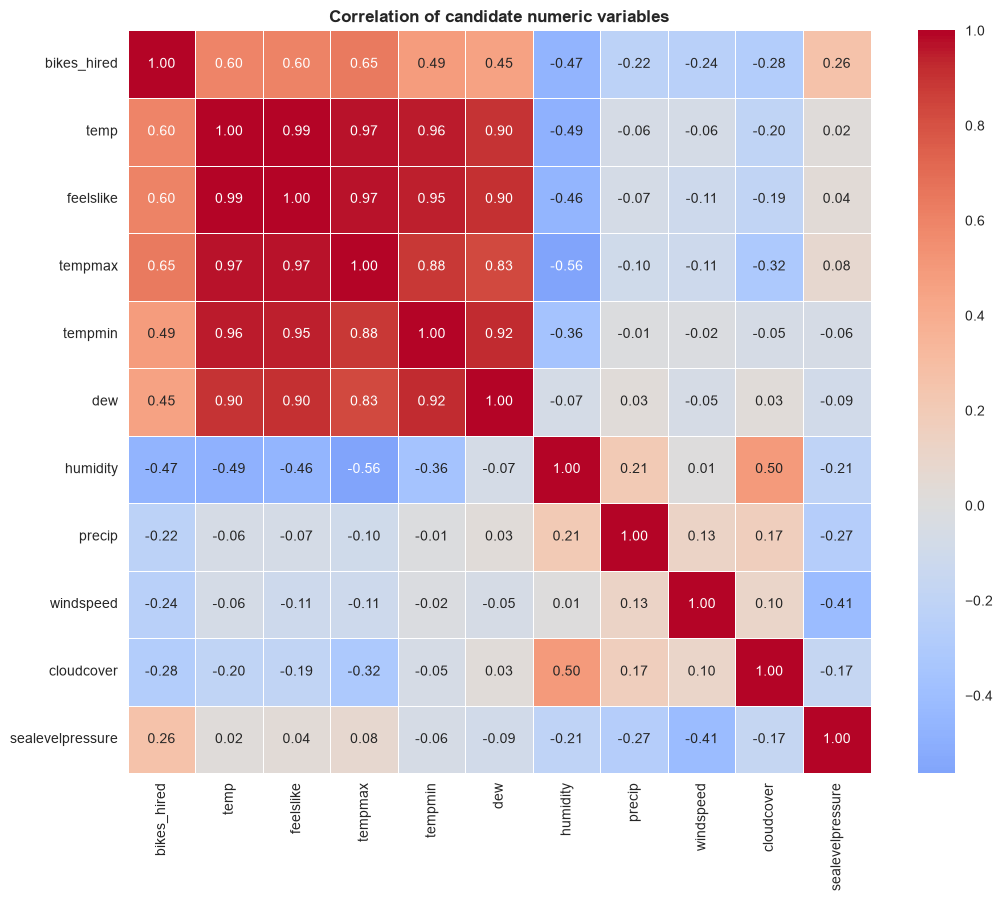

In [4]:
weather_vars = ['bikes_hired', 'temp', 'feelslike', 'tempmax', 'tempmin', 'dew',
                'humidity', 'precip', 'windspeed', 'cloudcover', 'sealevelpressure']
plt.figure(figsize=(11, 9))
sns.heatmap(bike[weather_vars].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation of candidate numeric variables', fontweight='bold')
plt.tight_layout(); plt.show()

# >>> Optional: explore hires by day_of_week, month, or season here

In [5]:
# All the columns available in the dataset
bike.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4383 entries, 1251 to 5633
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   date              4383 non-null   datetime64[ns, UTC]
 1   bikes_hired       4383 non-null   int64              
 2   tempmax           4383 non-null   float64            
 3   tempmin           4383 non-null   float64            
 4   temp              4383 non-null   float64            
 5   feelslikemax      4383 non-null   float64            
 6   feelslikemin      4383 non-null   float64            
 7   feelslike         4383 non-null   float64            
 8   dew               4383 non-null   float64            
 9   humidity          4383 non-null   float64            
 10  precip            4383 non-null   float64            
 11  precipprob        4383 non-null   int64              
 12  precipcover       4383 non-null   float64            
 13  preci

**Write-up (2 to 3 sentences):** which variables do you expect to matter most, and which pairs look worryingly similar?

Daily hires seem to be mostly affected by temperature and humidity. Warmer days usually have more hires, while higher humidity tends to reduce them. Rain, wind, and cloud cover also seem to reduce hires, but their effect is weaker. Since temperature variables like `temp`, `feelslike`, `tempmax`, `tempmin`, and `dew` are very similar to each other, we will only keep one of them to avoid using repeated information.


## A worked example: fit, check, and predict the future

Before you build your own model in Part 2, here is the whole workflow on a deliberately simple model: bikes hired on temperature, humidity, and day of the week. Read it as a template. Your job in Part 2 is to do better than this, but the mechanics of fitting, checking, and forecasting are exactly the same.

### Fit the model

We use the formula interface, so we name the variables and let `statsmodels` build the design matrix. `C(day_of_week)` tells it to treat the day as a categorical, with Monday as the baseline.

In [6]:
# Fit: bikes hired on temperature, humidity, and day of week
example_model = smf.ols('bikes_hired ~ temp + humidity + C(day_of_week)', data=bike).fit()

# Coefficients, with their standard errors and p-values
print(example_model.summary2().tables[1].round(2))
print("\nAdj R-squared:", round(example_model.rsquared_adj, 4))
print("Residual SE:", round(example_model.scale ** 0.5, 1))

                          Coef.  Std.Err.      t  P>|t|    [0.025    0.975]
Intercept              33530.18   1040.93  32.21   0.00  31489.42  35570.93
C(day_of_week)[T.Tue]   2382.29    383.91   6.21   0.00   1629.63   3134.94
C(day_of_week)[T.Wed]   2389.06    383.80   6.22   0.00   1636.62   3141.49
C(day_of_week)[T.Thu]   2385.15    383.89   6.21   0.00   1632.53   3137.76
C(day_of_week)[T.Fri]    788.34    383.87   2.05   0.04     35.75   1540.93
C(day_of_week)[T.Sat]  -1393.71    383.90  -3.63   0.00  -2146.36   -641.06
C(day_of_week)[T.Sun]  -3690.57    383.87  -9.61   0.00  -4443.16  -2937.98
temp                     813.11     21.56  37.72   0.00    770.84    855.37
humidity                -203.57     11.05 -18.43   0.00   -225.23   -181.91

Adj R-squared: 0.4534
Residual SE: 6791.4


Read the coefficients as effects, holding the others fixed: each extra degree of temperature adds roughly 800 hires, each extra point of humidity removes about 200, and the day-of-week terms show the weekly pattern (Saturdays and especially Sundays sit well below a Monday). The adjusted R-squared tells you what share of the daily variation this simple model explains.

### Check it

Run the four-panel diagnostics, then compute the VIF (Variance Inflation Factor) directly with statsmodels on the two numeric predictors, to confirm they are not collinear.

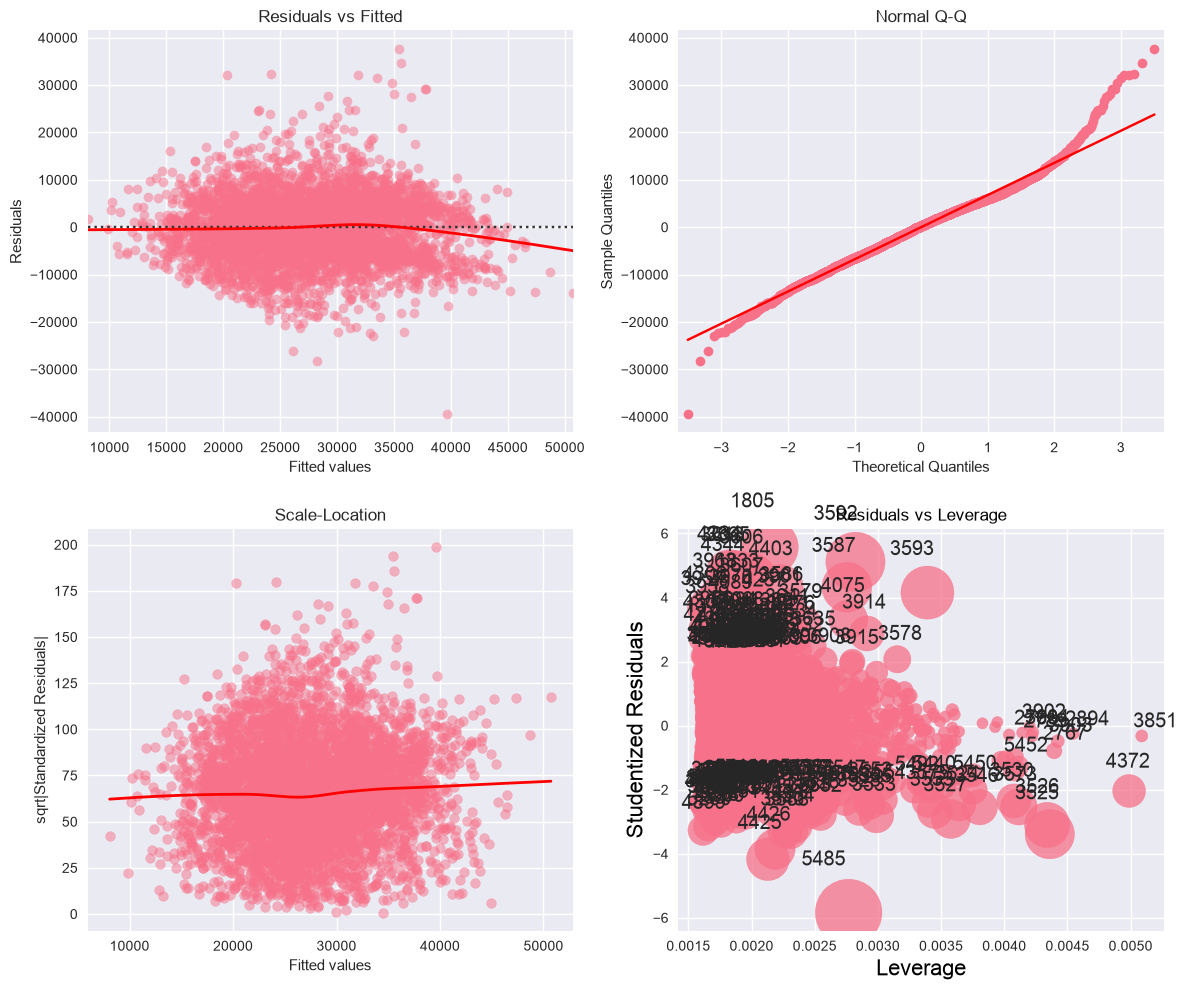

In [7]:
plot_model_diagnostics(example_model)

In [8]:
# VIF straight from statsmodels: how much each predictor is explained by the others
X = bike[['temp', 'humidity']]
vif = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif)

    feature       VIF
0      temp  4.094396
1  humidity  4.094396


### Predict the future

Two different jobs use the same `predict` method.

The **fitted values** are the model's prediction for every day it was trained on. They are what the diagnostics above are built from.

In [9]:
# One predicted value per day already in the data
bike['predicted_hires'] = example_model.fittedvalues
bike[['date', 'day_of_week', 'temp', 'humidity', 'bikes_hired', 'predicted_hires']].head()

,date,day_of_week,temp,humidity,bikes_hired,predicted_hires
1251,2014-01-01 00:00:00+00:00,Wed,7.9,90.0,4327,24021.595905
1252,2014-01-02 00:00:00+00:00,Thu,8.1,85.3,15820,25137.083096
1253,2014-01-03 00:00:00+00:00,Fri,8.1,81.3,11636,24354.548362
1254,2014-01-04 00:00:00+00:00,Sat,7.1,87.4,6918,20117.622978
1255,2014-01-05 00:00:00+00:00,Sun,4.9,90.0,9145,15502.646444


To **forecast the future**, build a small DataFrame with the conditions you expect, using the same column names as the predictors (`temp`, `humidity`, `day_of_week`), and pass it to `predict`. Here we ask: what if the next few days look like this?

In [10]:
# What we expect the weather to be on the next few days
future = pd.DataFrame({
    'temp':        [18, 22, 15, 12],
    'humidity':    [70, 55, 85, 90],
    'day_of_week': ['Mon', 'Wed', 'Sat', 'Sun'],
})
# match the categorical so the day-of-week effect lines up
future['day_of_week'] = pd.Categorical(future['day_of_week'], categories=day_order, ordered=True)

future['predicted_hires'] = example_model.predict(future).round(0)
future

,temp,humidity,day_of_week,predicted_hires
0,18,70,Mon,33916.0
1,22,55,Wed,42611.0
2,15,85,Sat,27030.0
3,12,90,Sun,21276.0


A single number hides the uncertainty. `get_prediction` adds intervals: `mean_ci` is the range for the average day under these conditions, and the wider `obs_ci` is the range for one actual future day, which is the honest one to quote when you forecast a specific day.

In [11]:
example_model.get_prediction(future).summary_frame(alpha=0.05).round(0)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,33916.0,297.0,33334.0,34499.0,20589.0,47244.0
1,42611.0,365.0,41897.0,43326.0,29278.0,55945.0
2,27030.0,300.0,26441.0,27618.0,13702.0,40357.0
3,21276.0,306.0,20675.0,21876.0,7948.0,34604.0


## Part 2 — Build your best model

Start from the baseline below (hires on temperature alone) and improve it. Add variables that make business sense, compare models, and keep the one you can defend. Some ideas: bring in `day_of_week`, precipitation, humidity, wind, and a seasonal term. Prefer the model that explains the data well **and** stays simple enough to interpret.

Two rules for today that keep your model compatible with the app you deploy later:

- use **numeric weather variables plus `C(day_of_week)`** as your predictors,
- keep the outcome as plain `bikes_hired` (no logs or transforms).

Judge models on adjusted R-squared and the residual standard error, not R-squared alone.

In [12]:
# Provided baseline
baseline = smf.ols('bikes_hired ~ temp', data=bike).fit()
print("Baseline: bikes_hired ~ temp")
print("  Adj R-squared:", round(baseline.rsquared_adj, 4), " Residual SE:", round(baseline.scale ** 0.5, 1))

# --- Step 1: the scheme changed in 2023 ---
# Average daily hires dropped by about 6,000 from 2023 on, so a model fitted to all years
# carries the old level into the future. We train on the current regime, 2023 onwards.
yearly = bike.groupby(bike['date'].dt.year)['bikes_hired'].mean().round(0)
print("\nAverage daily hires by year:")
print(yearly.to_string())

recent = bike[bike['date'] >= pd.Timestamp('2023-01-01', tz='UTC')].copy()
print(f"\nTraining data: {len(recent)} days from 2023 onwards")

# --- Step 2: judge candidates on how well they forecast the future ---
# Fit on 2023-2024, predict 2025, and score the error on the year not seen.
holdout_start = pd.Timestamp('2025-01-01', tz='UTC')

def forward_rmse(formula, data):
    train = data[data['date'] < holdout_start]
    test = data[data['date'] >= holdout_start]
    pred = smf.ols(formula, data=train).fit().predict(test)
    return np.sqrt(np.mean((test['bikes_hired'] - pred) ** 2))

weather4 = 'temp + humidity + precip + windspeed'
candidates = {
    'temp only':                         ('bikes_hired ~ temp',                                     bike),
    'temp + day of week':                ('bikes_hired ~ temp + C(day_of_week)',                    bike),
    '4 weather + day, all years':        (f'bikes_hired ~ {weather4} + C(day_of_week)',             bike),
    '4 weather + day, 2023 onwards':     (f'bikes_hired ~ {weather4} + C(day_of_week)',             recent),
    '4 weather + solar + day, 2023 on':  (f'bikes_hired ~ {weather4} + solarradiation + C(day_of_week)', recent),
}
rows = []
for name, (formula, data) in candidates.items():
    fit = smf.ols(formula, data=data).fit()
    rows.append({'model': name, 'n_days': int(fit.nobs), 'adj_R2': round(fit.rsquared_adj, 3),
                 'resid_SE': round(fit.scale ** 0.5), 'forecast_RMSE_2025': round(forward_rmse(formula, data))})
print("\n", pd.DataFrame(rows).to_string(index=False))

# --- Step 3: the chosen model ---
best_model = smf.ols(f'bikes_hired ~ {weather4} + solarradiation + C(day_of_week)', data=recent).fit()
print("\nChosen: bikes_hired ~ temp + humidity + precip + windspeed + solarradiation + C(day_of_week), fitted on 2023 onwards")
print(best_model.summary2().tables[1].round(1))
print("\nAdj R-squared:", round(best_model.rsquared_adj, 3), " Residual SE:", round(best_model.scale ** 0.5))


Baseline: bikes_hired ~ temp
  Adj R-squared: 0.3593  Residual SE: 7353.0

Average daily hires by year:
date
2014    27463.0
2015    27046.0
2016    28152.0
2017    28619.0
2018    28952.0
2019    28562.0
2020    28509.0
2021    29976.0
2022    31523.0
2023    23373.0
2024    23957.0
2025    24840.0

Training data: 1096 days from 2023 onwards

                            model  n_days  adj_R2  resid_SE  forecast_RMSE_2025
                       temp only    4383   0.359      7353                7313
              temp + day of week    4383   0.411      7049                6755
      4 weather + day, all years    4383   0.512      6420                7428
   4 weather + day, 2023 onwards    1096   0.677      3536                3945
4 weather + solar + day, 2023 on    1096   0.685      3491                3911

Chosen: bikes_hired ~ temp + humidity + precip + windspeed + solarradiation + C(day_of_week), fitted on 2023 onwards
                         Coef.  Std.Err.     t  P>|t|   [0.02

**Write-up (3 to 4 sentences):** which model did you choose and why? What does each coefficient tell the planners in plain words (for example, the effect of one extra degree, or of a rainy day)?

We used data from 2023 onwards because it predicts recent hires better. The final model uses weather and day of the week and explains about 69% of the variation in hires. Warmer and sunnier days increase hires, while humidity, rain, and wind reduce them. Hires are also highest from Tuesday to Thursday, showing that the scheme is mainly used for midweek commuting.



### Extra: does a nonlinear model beat the linear one?

We fit **XGBoost** (gradient-boosted trees) on the same predictors and the same 2023-onwards data, and score both models the same two ways: 5-fold cross-validation, and the forward test (fit on 2023 to 2024, predict 2025).

In [13]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

numeric_vars = ['temp', 'humidity', 'precip', 'windspeed', 'solarradiation']
X = recent[numeric_vars].copy()
for d in day_order[1:]:                       # one-hot day of week, Monday as baseline
    X[f'day_{d}'] = (recent['day_of_week'] == d).astype(int)
y = recent['bikes_hired'].values
train = (recent['date'] < holdout_start).values
test = ~train

def rmse(a, p):
    return float(np.sqrt(np.mean((a - p) ** 2)))

rows = []
for name, learner in [('Linear (OLS)', LinearRegression()),
                      ('XGBoost', XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=3,
                                               subsample=0.8, random_state=42))]:
    cv_pred = cross_val_predict(learner, X, y, cv=KFold(5, shuffle=True, random_state=42))
    learner.fit(X[train], y[train])
    test_pred = learner.predict(X[test])
    rows.append({'model': name,
                 'CV RMSE': round(rmse(y, cv_pred)),
                 'CV R2': round(1 - np.sum((y - cv_pred) ** 2) / np.sum((y - y.mean()) ** 2), 3),
                 'forecast RMSE 2025': round(rmse(y[test], test_pred)),
                 'forecast R2 2025': round(1 - np.sum((y[test] - test_pred) ** 2) / np.sum((y[test] - y[test].mean()) ** 2), 3)})
print(pd.DataFrame(rows).to_string(index=False))


       model  CV RMSE  CV R2  forecast RMSE 2025  forecast R2 2025
Linear (OLS)     3521  0.680                3911             0.626
     XGBoost     3325  0.714                3736             0.658


**What we conclude.** XGBoost is a little better on both tests, about 5 percent lower forecast error on 2025 (roughly 3,700 hires against 3,900). That gain is real but small, and it costs the things the planners and the dashboard need: readable coefficients, the VIF and residual checks, and a simple coefficients file. We keep the linear model and report XGBoost as the alternative we tested.

## Part 3 — Check for multicollinearity with VIF

When two predictors carry nearly the same information (think `temp`, `feelslike`, and `dew`), the model struggles to tell their effects apart. Coefficients get unstable and standard errors blow up. The Variance Inflation Factor measures how much each predictor is explained by the others.

Rule of thumb: a VIF near 1 is fine, above about 5 is a warning, and above about 10 usually means the variable is redundant and should go.

Compute the VIF directly with statsmodels' `variance_inflation_factor` on the **numeric** predictors in your model (the pattern is in the cell below). If anything is badly inflated, drop the worst offender, refit, and check again. Keep the variable that is easier to explain to a planner.

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def vif_table(df, cols):
    """Centred VIFs: the constant is added so the VIF measures how much each
    predictor is explained by the others, not its distance from zero."""
    X = sm.add_constant(df[cols])
    return pd.DataFrame({'feature': cols,
                         'VIF': [variance_inflation_factor(X.values, i + 1) for i in range(len(cols))]}).round(2)

# 1) The numeric predictors in our best model
numeric_vars = ['temp', 'humidity', 'precip', 'windspeed', 'solarradiation']
print("VIF, final model:")
print(vif_table(recent, numeric_vars).to_string(index=False))

# 2) What collinearity looks like: add feelslike next to temp
print("\nVIF, with feelslike added next to temp:")
print(vif_table(recent, ['temp', 'feelslike'] + numeric_vars[1:]).to_string(index=False))
collinear = smf.ols('bikes_hired ~ temp + feelslike + humidity + precip + windspeed + solarradiation + C(day_of_week)',
                    data=recent).fit()
print("\nTemperature coefficient with feelslike in the model:",
      round(collinear.params['temp']), " (SE", round(collinear.bse['temp']), ")")
print("Temperature coefficient in the final model:         ",
      round(best_model.params['temp']), " (SE", round(best_model.bse['temp']), ")")

# 3) Nothing in the final model is inflated, so nothing is dropped and best_model stands.


VIF, final model:
       feature  VIF
          temp 1.54
      humidity 2.60
        precip 1.21
     windspeed 1.05
solarradiation 2.45

VIF, with feelslike added next to temp:
       feature   VIF
          temp 99.22
     feelslike 95.96
      humidity  2.70
        precip  1.21
     windspeed  1.13
solarradiation  2.45

Temperature coefficient with feelslike in the model: -209  (SE 189 )
Temperature coefficient in the final model:          443  (SE 24 )


**Write-up (2 to 3 sentences):** which variables (if any) were collinear, what did you drop, and what happened to the coefficients and standard errors afterwards?

The final model has low VIF values, so multicollinearity is not a problem. Adding `feelslike` with `temp` causes very high VIFs and an unstable temperature coefficient because both variables contain almost the same information. Therefore, we keep only `temp`, which gives a more stable result and is easier to use in forecasts.



## Part 4 — Diagnose your final model

Run the four-panel diagnostics on your final model. Look for leftover pattern in Residuals vs Fitted, heavy tails in the Q-Q plot, a fan shape in Scale-Location, and any single day with outsized leverage. Note anything the planners should be aware of, for example that the model tends to under-predict on the very busiest days.

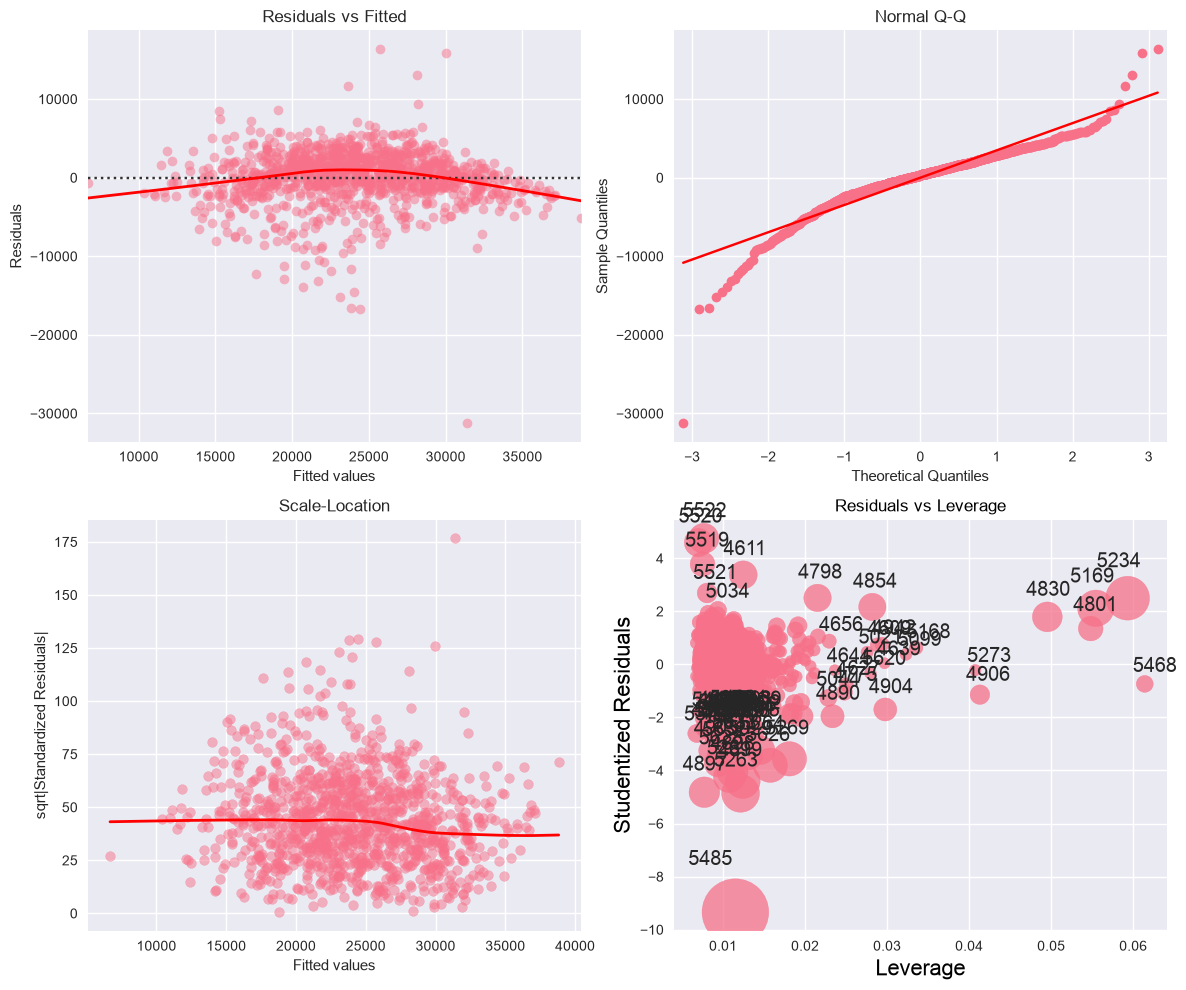

Most under-predicted days (actual far above the model):
      date day_of_week  temp  precip  bikes_hired  predicted  residual
2025-09-11         Thu  14.5   2.981        42067    25715.0   16352.0
2025-09-09         Tue  15.9   0.000        45823    29992.0   15831.0
2025-09-08         Mon  17.3   0.000        41193    28131.0   13062.0
2023-03-15         Wed   4.0   1.154        35319    23663.0   11656.0
2025-09-10         Wed  15.9   0.724        37537    28210.0    9327.0

Most over-predicted days (actual far below the model):
      date day_of_week  temp  precip  bikes_hired  predicted  residual
2025-08-05         Tue  18.1   0.000          188    31390.0  -31202.0
2024-12-26         Thu   7.0   0.002         7741    24436.0  -16695.0
2023-12-26         Tue   8.0   0.016         7214    23807.0  -16593.0
2023-12-28         Thu  11.7   0.300         7956    23085.0  -15129.0
2024-12-24         Tue   9.7   0.199         9441    24035.0  -14594.0


In [15]:
plot_model_diagnostics(best_model)

# Which days does the model get most wrong? Positive residual = more hires than predicted.
resid_df = recent[['date', 'day_of_week', 'temp', 'precip', 'bikes_hired']].copy()
resid_df['predicted'] = best_model.fittedvalues.round(0)
resid_df['residual'] = best_model.resid.round(0)
resid_df['date'] = resid_df['date'].dt.date
print("Most under-predicted days (actual far above the model):")
print(resid_df.nlargest(5, 'residual').to_string(index=False))
print("\nMost over-predicted days (actual far below the model):")
print(resid_df.nsmallest(5, 'residual').to_string(index=False))


**Write-up (2 to 3 sentences):** do the assumptions look reasonable? Where does the model struggle?

The model assumptions mostly look fine, but a few unusual days affect the residuals, such as Christmas, a possible system outage, and the Tube strike. So, the model should be used as a weather-and-weekday baseline, with manual adjustments for holidays and major events.




## Part 5 — Export your model for the dashboard

The dashboard does not need Python to re-fit anything. It just needs your model's coefficients. The helper below writes them to a plain two-column CSV, `model_coefficients.csv`: one row per term (`Intercept`, each numeric variable, and one `day_...` row per weekday) and its value. This small file is the contract between your analysis and your dashboard.

Set `numeric_vars` to exactly the numeric predictors in your final model, then run the cell. Open the CSV and check the numbers match your model summary.

In [16]:
# Where the dashboard gets each input from Open-Meteo (daily variables), and any unit conversion.
# The dataset's solarradiation is a daily mean in W/m2; Open-Meteo's shortwave_radiation_sum is
# in MJ/m2 per day, so the app must multiply it by 11.57 (1e6 / 86400).
sources = {
    'temp':           'open-meteo temperature_2m_mean (C)',
    'humidity':       'open-meteo relative_humidity_2m_mean (%)',
    'precip':         'open-meteo precipitation_sum (mm)',
    'windspeed':      'open-meteo wind_speed_10m_max (km/h)',
    'solarradiation': 'open-meteo shortwave_radiation_sum (MJ/m2) multiplied by 11.57',
}

def export_coefficients(model, numeric_vars, path="model_coefficients.csv"):
    """Write a fitted 'bikes_hired ~ <numeric> + C(day_of_week)' model to a CSV:
    term, coefficient, source. Prediction = Intercept + sum(coefficient * value) + day_<weekday>."""
    rows = [("Intercept", model.params["Intercept"], "model fitted on 2023 onwards")]
    for v in numeric_vars:
        rows.append((v, model.params[v], sources.get(v, "")))
    for d in day_order:  # Monday is the baseline, so its effect is 0
        coef = 0.0 if d == "Mon" else model.params.get(f"C(day_of_week)[T.{d}]", 0.0)
        rows.append((f"day_{d}", coef, "baseline" if d == "Mon" else "added for that weekday"))
    coeffs = pd.DataFrame(rows, columns=["term", "coefficient", "source"])
    coeffs.to_csv(path, index=False)
    print("Wrote", path)
    return coeffs

numeric_vars = ['temp', 'humidity', 'precip', 'windspeed', 'solarradiation']
coeffs = export_coefficients(best_model, numeric_vars)
coeffs


Wrote model_coefficients.csv


,term,coefficient,source
0,Intercept,29085.727010,model fitted on 2023 onwards
1,temp,443.008791,open-meteo temperature_2m_mean (C)
2,humidity,-95.121513,open-meteo relative_humidity_2m_mean (%)
3,precip,-284.258095,open-meteo precipitation_sum (mm)
4,windspeed,-185.094529,open-meteo wind_speed_10m_max (km/h)
5,solarradiation,14.665807,open-meteo shortwave_radiation_sum (MJ/m2) mul...
6,day_Mon,0.000000,baseline
7,day_Tue,2381.303753,added for that weekday
8,day_Wed,2862.314081,added for that weekday
9,day_Thu,2516.736856,added for that weekday


## Part 6 — Build and deploy the dashboard with an LLM

You will not hand-write the dashboard. Instead you will brief an LLM (Claude, ChatGPT, or similar) to generate it, run it, and deploy it. This is the point of the exercise: you own the model and the data, and you direct the tool to build the software around them.

### What the dashboard must do

It is an **interactive exploration of the London bikes dataset**, built with **Dash** (not Streamlit) and deployed as a live web service on **Render**. It has two parts:

- **Explore the data.** Load the bikes dataset and let a planner interact with it: for example a dropdown to choose a weather variable (temperature, humidity, precipitation, wind, cloud) and see how daily hires respond, with the option to colour by weekend or season, plus the average hires by day of week. Make it genuinely interactive, not a static picture.
- **Predict.** Read your `model_coefficients.csv` and apply the model to real weather from Open-Meteo. Show the predicted hires for the **first week of January 2026**, and for the next five days. Because January 2026 is in the past, that week's weather comes from Open-Meteo's historical archive; the five-day part is the live forecast.

You already have `open_meteo.py` in this folder. It has `open_meteo(location, days_to_forecast)` for the live forecast and `open_meteo_history(location, start_date, end_date)` for a past date range, both returning `date, day_of_week, temp, humidity, precip, windspeed, cloudcover`. Include this file in your repo so the app can import it. Open-Meteo is free and needs no API key.

### Step by step

1. **Try the weather helpers** in a quick cell to see what your app will receive: `from open_meteo import open_meteo, open_meteo_history`, then `open_meteo("London", 5)` and `open_meteo_history("London", "2026-01-01", "2026-01-07")`. No key, no sign-up.
2. **Brief the LLM.** Paste the prompt below, together with your `model_coefficients.csv` and the contents of `open_meteo.py`, into your LLM of choice.
3. **Run it locally with uv.** Put the files the LLM gives you (plus `open_meteo.py` and `model_coefficients.csv`) in a folder, run `uv sync` to set up the environment from `pyproject.toml` (or `uv add dash plotly pandas requests gunicorn` if you are starting from scratch), then `uv run python app.py` and open the local URL.
4. **Push to GitHub.** Create a public repo and commit `app.py`, `open_meteo.py`, `model_coefficients.csv`, `pyproject.toml`, and any deployment files (commit `uv.lock` too for reproducible builds).
5. **Deploy on Render.** Create a free account, choose New Web Service, connect your repo, and set the build command to `pip install uv && uv sync` and the start command to `uv run gunicorn app:server`. No API key or environment variable is needed. Deploy, wait for the build, and open the live URL.
6. **Paste your live URL at the bottom of this notebook.**

### The prompt to give your LLM

Copy everything between the lines, and paste your real `model_coefficients.csv` and `open_meteo.py` where indicated.

---

> You are helping me build and deploy a small data dashboard. Build a **Dash** application (not Streamlit) in a single `app.py` with two tabs:
>
> 1. **Explore the data.** Load the London bikes dataset from `https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data/london_bikes.csv` (columns include `bikes_hired`, `temp`, `humidity`, `precip`, `windspeed`, `cloudcover`, `day_of_week`, `weekend`, `season_name`). Let the user pick a weather variable from a dropdown and see a scatter of daily `bikes_hired` against it, with a control to colour by `weekend` or `season_name`, plus a bar chart of average hires by day of week.
> 2. **Predict.** Load a linear model from `model_coefficients.csv` (two columns: `term`, `coefficient`; terms are `Intercept`, the numeric variables, and `day_Mon`..`day_Sun`). A day's prediction is `Intercept + sum(coefficient * value)` over the numeric terms, plus the `day_<weekday>` coefficient. Get weather from a helper `open_meteo.py` (I already have it): `open_meteo_history("London", "2026-01-01", "2026-01-07")` for the first week of January 2026, and `open_meteo("London", 5)` for the next five days. Both return a DataFrame with `date, day_of_week, temp, humidity, precip, windspeed, cloudcover`. Show a table and a bar chart of predicted `bikes_hired` for each.
>
> Expose `server = app.server` for gunicorn and listen on the `PORT` environment variable. I manage dependencies with **uv**, so give me a `pyproject.toml` (dash, plotly, pandas, requests, gunicorn), not a `requirements.txt`, and a `render.yaml` to deploy on Render (build command `pip install uv && uv sync`, start command `uv run gunicorn app:server`). No API key is needed. Handle a failed request gracefully so the page still loads.
>
> Here are my `model_coefficients.csv` and `open_meteo.py`:
>
> ```
> (paste the contents of your model_coefficients.csv here)
> ```
> ```python
> (paste the contents of open_meteo.py here)
> ```

---

If the app misbehaves, iterate with the LLM: paste the error, show the data or Open-Meteo response, and ask it to fix the specific problem.

## Submission checklist

- [ ] Best model chosen and justified (Part 2 write-up done)
- [ ] VIF computed, collinearity treated (Part 3 write-up done)
- [ ] Diagnostics run and interpreted (Part 4 write-up done)
- [ ] `model_coefficients.csv` exported (Part 5)
- [ ] Dashboard runs locally: interactive exploration works, and it predicts the first week of January 2026
- [ ] Code pushed to a public GitHub repo
- [ ] Dashboard deployed on Render and opens at a live URL

**Our GitHub repo:** _paste link_

**Our live Render URL:** _paste link_